# 1. Average 

## 1A. What is the average rool of a six-sided die?

To get the average roll of a six-sided die you can either do it by hand, $\frac{1}{n}\sum_{i=1}^n roll_i$ or apply the Monte Carlo way, roll the die 200.000 times and average the results.

In [8]:
import numpy as np
rng = np.random.default_rng(42)

In [ ]:
n = 200_000     # dice rolls
rolls = rng.integers(1, (6+1), n)

print('simulated average:', rolls.mean())

simulated average: 3.502735


## 1B. What happend if two dices are rolled and averaging the higher number among them?

Let roll two dice and keep only the higher of the two. What is the average of that higher number? Thi is no longer obvious. Doing it by hand means listing all $n$ outcomes, finding the higher value in each, and averaging.

In [10]:
dices = 2
pairs = rng.integers(1, (6+1), size=(n, dices))
higher = pairs.max(axis=1)

print('simulated average:', higher.mean())

simulated average: 4.47127


## 1C. Three workers problem
Three builders work at the same time on separte parts of a job. Each takes somewhere between 4 and 10 days, any value in that range equally likely. The job is finished when the __last__ builder finishes.

Each bulder averages 7 days. So the job averages 7 days? This reasoning is wrong,

In [11]:
workers = 3
days = rng.uniform(4, 10, size=(n, workers))
finish = days.max(axis=1)

print('average time for one builder:', days.mean())
print('average time for the jon:', finish.mean())

average time for one builder: 6.999745815594027
average time for the jon: 8.49841590873256


* Why 8.5 and not 7?
For the job to come in at 5 days, __all three__ builders must happen to be fast. For it to run to 9 days, only __one__ ofthem needs to be slow. Bad luck spreads; good luck has to be unanomous. So the finishing time is pulled upwards.

This is why a project plan built by adding up average task times is systematically optimistic, and why the error grows as you add more parallel tasks.

## 1D. The procedure
Every example above had the same three steps:
1. **Generate** many random versions of the situation.
2. **Measure** the thing under study in each one.
3. **Average** those measurements.

| Example | Generate | Measure |
|---|---|---|
| One die | 200,000 rolls | the number rolled |
| Two dice | 200,000 pairs | the higher of the pair |
| The job | 200,000 sets of 3 builders | the slowest builder |

## 1F. What happend if 1C is run five times?
The mean result will vary in each run.

In [12]:
def job(n):
    "Simulate n jobs, return the finishing time of each."
    return rng.uniform(4, 10, size=(n, 3)).max(axis=1)

for i in range(5):
    print(f'run {i+1}:  {job(1000).mean():.3f}')

run 1:  8.530
run 2:  8.476
run 3:  8.500
run 4:  8.492
run 5:  8.486


## 1G. Measuring the standard error (SE)
* standard deviation. Some jobs finish in 6 dayts, others in 10. This spread is large and does not shrink no matter how many jobs are simulated.
* standard error. Section 1F showed the averages of 1.000 jobs landing between 8.49 and 8.55. This spread is small, and it does shrink as it is simulated more.

In [28]:
one_run = job(200_000)
print('standard deviation:', round(one_run.std(), 3)) # 3 decimals

# Doing the whole 1000-job experiemt 2000 separate times, resulting in scattered answers.
averages = np.array([job(1000).mean() for _ in range(2000)])
print('standard error:', round(averages.std(), 4))

standard deviation: 1.158
standard error: 0.0374


Individual jobs scatters by about 1.16, but the average of 1.000 jobs scatters by only about 0.037 days. 

The _standard error_ (SE) can be found as follows,
$$
    \text{SE} = \frac{\sigma}{\sqrt{n}}
$$

In [19]:
n = 1000
std_error = one_run.std() / np.sqrt(n)

print('measured (2000 repeats)', round(averages.std(), 4))
print('SE one run:', round(std_error, 4))

measured (2000 repeats) 0.0368
SE one run: 0.0367


Because the SE is divided by $\sqrt{n}$ rather than by $n$, simulating more helps, but slowly. Quadruple the number of simulations and the error only __halves__.

In [20]:
print(f"{'simulations':>12} {'SE':>9}")
for n in [100, 400, 1600, 6400]:
    a = np.array([job(n).mean() for _ in range(2000)])
    print(f'{n:>12} {a.std():>9.4f}')

 simulations        SE
         100    0.1152
         400    0.0586
        1600    0.0294
        6400    0.0146


Each row uses four times as many simulations as the one above it, and each SE is about the half the one above it. Four times the work for twice the accuracy.

Knowing that the real average is 8.5 and the SE is about 0.037, the next step is turning those into a statement like "_the truth is between 8.46 and 8.60_". 

To do that, it is needed to know how the SEs are distributed, are they usually tiny with the occasional huge miss, or are they all about the same size? 

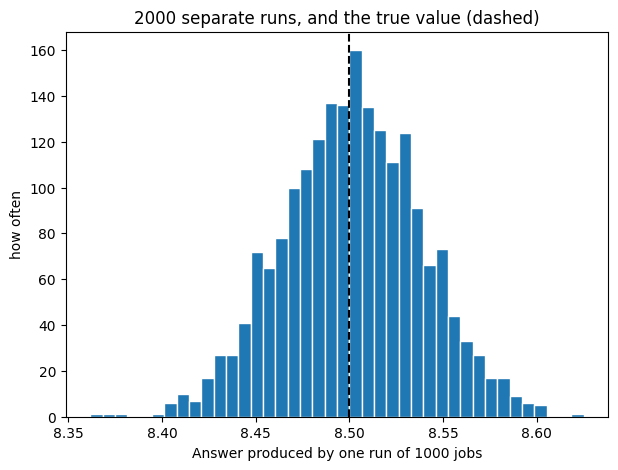

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.hist(averages, bins=40, edgecolor='white')
plt.axvline(8.5, color='k', ls='--')
plt.xlabel('Answer produced by one run of 1000 jobs')
plt.ylabel('how often')
plt.title('2000 separate runs, and the true value (dashed)')
plt.show()

The previous figure has a _bell shape_, centered on the truth. The bell shape shows how 95\% of the values sit within __about__ two SEs of the center. Not exactly two, the precise number is 1.96.  

In [ ]:
std_error = one_run.std() / np.sqrt(1000)
within = np.abs(averages - 8.5) < 1.96 * std_error

print('fraction of the 2000 answer within 1.96 SEs of the truth:')
print(f'{round(within.mean(), 3)}%')


fraction of the 2000 answer within 1.96 SEs of the truth:
0.95%


## 1H. Monte Carlo result report
To report a Monte Carlo result
$$
    \hat{\theta}_n \pm 1.96 \frac{s}{\sqrt{n}}
$$
where 1.96 gives a 95\% of confident (1.645 for 90\% and 2.576 for 99\%).
$$
    \text{answer} \pm 1.96 \times SE
$$
For the workers problem: $8.53 \pm 0.07$ days, given a 95\% chance the true time is in this interval.

| Plain words | Symbol | Name |
|---|---|---|
| true answer | $\theta$ | *theta* — the target |
| simulated answer | $\hat\theta_n$ | *theta hat* — the estimate |
| how many simulations were run | $n$ | the sample size |
| the random situation being simulated | $X$ | the random variable |
| what is measured in each simulation | $f$ | the function being averaged |
| "the average of" | $\mathbb{E}[\ \cdot\ ]$ | the expectation |
| spread of the individual results | $\sigma$ | *sigma* — the standard deviation |
| **the wobble** | $\sigma/\sqrt{n}$ | the **standard error** |
| the wobble estimation | $s/\sqrt{n}$ | $s$ is sigma measured from your sample |

## 1I. Exercises

### 1I1. Exercise 1 — coin flips

Flip a fair coin 10 times. What is the chance of getting **7 or more heads**?

Simulate 200,000 sets of 10 flips, count how many sets had 7 or more heads, and
divide by 200,000. Exact answer: **0.1719**.

Hint: `rng.integers(0, 2, size=(200_000, 10))` gives you 200,000 rows of 10
coin flips, with 1 for heads. `.sum(axis=1)` counts the heads in each row.

*What this exercise teaches:* counting the fraction of simulations where
something happened is the same recipe as averaging. A chance is just the average
of a column of 0s and 1s.

In [ ]:
import numpy as np
rng = np.random.default_rng(42)

tries = 10      # coin flips
n = 200_000     # simulations
flips = rng.integers(0, 2, size=(n, tries)) # creates n arrays of tries size which can take 0 or 1 values
heads = flips.sum(axis=1)   # sum each array values over the n arrays

hits = (heads >= 7) # check how many simulations got 7 or more heads

p = hits.mean()     # get the mean of hits in the simulation
std_error = hits.std(ddof=1) / np.sqrt(n)   # get the SE by calculating hits' \sigma divided by \sqrt{n} 

print(f"{p:.4f} +/- {1.96*std_error:.4f}")

0.1718 +/- 0.0017


### 1I2. Exercise 2 — more builders

Change section 3 from three builders to **five**, all still taking 4 to 10 days.

Predict first, before running it: does the average job time go up, down, or stay
the same? Then check. Exact answer: **9.0 days**.

*What this exercise teaches:* the gap between "each task averages 7" and the
real answer widens as tasks are added. This is why large parallel projects
overrun far worse than small ones.

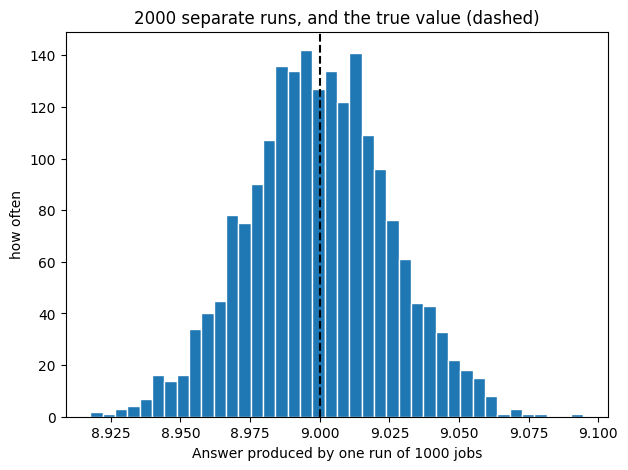

9.0154 +/- 0.0503


In [52]:
def job(n, workers):
    return rng.uniform(4, 10, size=(n, workers)).max(axis=1)

workers = 5
n = 1000
averages = np.array([job(n, workers).mean() for _ in range(2000)])

import matplotlib.pyplot as plt
plt.figure(figsize=(7,5))

plt.hist(averages, bins=40, edgecolor='white')
plt.axvline(9.0, color='k', ls='--')
plt.xlabel('Answer produced by one run of 1000 jobs')
plt.ylabel('how often')
plt.title('2000 separate runs, and the true value (dashed)')
plt.show()

days = job(n, workers)

p = days.mean()
std_error = days.std() / np.sqrt(n)

print(f"{p:.4f} +/- {1.96*std_error:.4f}")

### 1I3. Exercise 3 — quote your own wobble

Estimate the five-builder answer twice: once with 100 simulations, once with
10,000. For each, report the answer and its wobble using the formula from
section 6, then write out the full result as *answer ± 1.96 × wobble*.

Check whether the true value 9.0 falls inside each interval. Then note how much
narrower the second interval is than the first — and compare that narrowing with
the square-root rule from section 7.

*What this exercise teaches:* a Monte Carlo result without a wobble attached is
not a result.

8.9655 +/- 0.1716


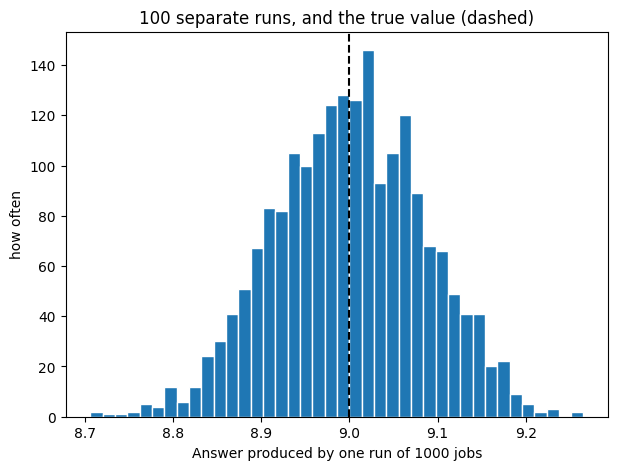

8.9913 +/- 0.0168


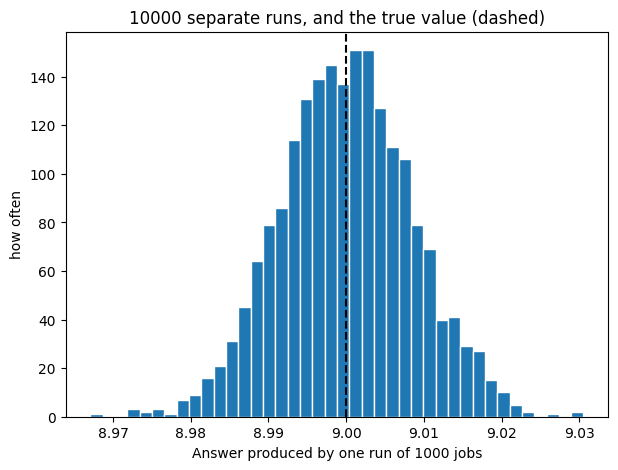

In [60]:
def job(n, workers):
    days = rng.uniform(4, 10, size=(n, workers))
    return days.max(axis=1)

workers = 5
n = [100, 10000]
for n_i in n:   
    days = job(n_i, workers)

    p = days.mean()
    std_error = days.std() / np.sqrt(n_i)
    print(f"{p:.4f} +/- {1.96*std_error:.4f}")
    
    averages = np.array([job(n_i, workers).mean() for _ in range(2000)])

    import matplotlib.pyplot as plt
    plt.figure(figsize=(7,5))

    plt.hist(averages, bins=40, edgecolor='white')
    plt.axvline(9.0, color='k', ls='--')
    plt.xlabel('Answer produced by one run of 1000 jobs')
    plt.ylabel('how often')
    plt.title(f'{n_i} separate runs, and the true value (dashed)')
    plt.show()

    

    